# RQ2 — Medicare Discharge Volume Prediction (Temporal Split)
### DSCI 5260 — Group 6 | Medicare Inpatient Utilization and Payment Analysis

**Research Question:**  
Can we predict the number of Medicare discharges for a hospital–DRG combination based on hospital characteristics, diagnosis severity, geography, and temporal trends?

**Why Temporal Split?**  
A random train/val/test split caused **data leakage** via `hosp_drg_te` — the same hospital-DRG pair appeared in both train and val across different years, letting the model "look up" answers. Splitting by year eliminates this entirely and reflects how the model would be used in practice: trained on past data, predicting future years.

**Split Strategy:**
- **Train:** 2017–2021 (learn historical patterns)
- **Validation:** 2022 (tune hyperparameters)
- **Test:** 2023 (final honest evaluation)
- **Predict:** 2024 (real-world forecast)

**Sections:**
- **4.1** Variable Definitions
- **4.2** Load & Split Data by Year
- **4.3** Step 1 — Baseline Model (Linear Regression)
- **4.4** Step 2 — Check Assumptions
- **4.5** Step 3 — Random Forest Regressor
- **4.6** Step 4 — XGBoost Regressor
- **4.7** Step 5 — Model Comparison (Validation Set)
- **4.8** Step 6 — Feature Importance & SHAP
- **4.9** Step 7 — Final Evaluation on Test Set
- **4.10** Step 8 — Predict 2024
- **4.11** Business Insights

> **Input:** `Medicare_Processed.parquet` (full dataset, split by `Data_Year`)  
> **Target:** `Log_Tot_Dschrgs` (log1p-transformed discharge count)


---
## 4.1 Variable Definitions

### Dependent Variable (Target)

| Variable | Raw Column | Model Column | Description |
|----------|-----------|--------------|-------------|
| Total Medicare discharges | `Tot_Dschrgs` | `Log_Tot_Dschrgs` | Log1p-transformed to handle right skew. Back-transform with `expm1()` to get discharge counts. |

---

### Independent Variables (Features)

#### Diagnosis Severity
| Feature | Column | Description |
|---------|--------|-------------|
| DRG complexity weight | `DRG_Weight` | CMS-assigned weight reflecting resource intensity. Higher weight = more complex procedure. |

#### Hospital Characteristics
| Feature | Column | Description |
|---------|--------|-------------|
| Hospital bed count | `BED_CNT` | Proxy for hospital size and capacity. Larger hospitals handle more discharges. |
| Hospital target encoding | `hosp_te` | Mean discharge volume for this hospital across all DRGs in the **training set only**. Captures hospital-level volume tendency. |
| DRG target encoding | `drg_te` | Mean discharge volume for this DRG across all hospitals in the **training set only**. Captures national DRG popularity. |

#### Geographic Factors
| Feature | Column | Description |
|---------|--------|-------------|
| Ownership dummies | `own_For-Profit`, `own_Non-Profit` | Hospital ownership type vs. Government (reference). |
| RUCA dummies | `ruca_Metropolitan`, `ruca_Micropolitan`, `ruca_Small Town` | Rural-Urban Commuting Area vs. Rural (reference). |

#### Temporal
| Feature | Column | Description |
|---------|--------|-------------|
| Data year | `Data_Year` | Calendar year of observation. Captures national discharge trend over time. |

---

### Why `hosp_drg_te` is EXCLUDED
`hosp_drg_te` encodes the mean discharges for each exact hospital-DRG pair. With random splits, the same pair appears in train and val across years, effectively letting the model look up the answer. It contributed 70.5% of SHAP importance and inflated R² to 0.90 — which was data leakage, not learning. The temporal split removes this risk entirely; `hosp_te` and `drg_te` are safe because they are averaged across many entities.


---
## 4.2 Load & Split Data by Year

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

PROCESSED_DIR = Path('..') / 'Data' / 'Processed_Data'

# ── Load full processed dataset ──
df = pd.read_parquet(PROCESSED_DIR / 'df_medidata_clean.parquet')

# ── Temporal split by year ──
df_train = df[df['Data_Year'] <= 2021].copy()
df_val   = df[df['Data_Year'] == 2022].copy()
df_test  = df[df['Data_Year'] == 2023].copy()
df_pred  = df[df['Data_Year'] == 2024].copy() if 2024 in df['Data_Year'].values else None

print(f'Train (2017–2021): {len(df_train):>8,}  rows')
print(f'Validation (2022): {len(df_val):>8,}  rows')
print(f'Test       (2023): {len(df_test):>8,}  rows')
if df_pred is not None:
    print(f'Predict    (2024): {len(df_pred):>8,}  rows')
else:
    print(f'Predict    (2024): not available in dataset')
print()
print('Year distribution in training set:')
print(df_train['Data_Year'].value_counts().sort_index())


Train (2017–2021):  886,236  rows
Validation (2022):  145,742  rows
Test       (2023):  146,427  rows
Predict    (2024): not available in dataset

Year distribution in training set:
Data_Year
2017    196086
2018    192068
2019    187719
2020    158374
2021    151989
Name: count, dtype: int64


In [2]:
# ── Safe Target Encoding — computed from TRAINING SET ONLY ──
# hosp_te  : mean discharges per hospital  (averaged across all DRGs in train)
# drg_te   : mean discharges per DRG       (averaged across all hospitals in train)
# These are safe because they generalise across many entities.
# hosp_drg_te is intentionally excluded — it is too granular and caused leakage.

hosp_mean = df_train.groupby('Rndrng_Prvdr_CCN')['Tot_Dschrgs'].mean().rename('hosp_te')
drg_mean  = df_train.groupby('DRG_Cd')['Tot_Dschrgs'].mean().rename('drg_te')

for df_split in [df_train, df_val, df_test]:
    df_split['hosp_te'] = df_split['Rndrng_Prvdr_CCN'].map(hosp_mean).fillna(hosp_mean.mean())
    df_split['drg_te']  = df_split['DRG_Cd'].map(drg_mean).fillna(drg_mean.mean())

if df_pred is not None:
    df_pred['hosp_te'] = df_pred['Rndrng_Prvdr_CCN'].map(hosp_mean).fillna(hosp_mean.mean())
    df_pred['drg_te']  = df_pred['DRG_Cd'].map(drg_mean).fillna(drg_mean.mean())

print('hosp_te sample (first 5):')
print(df_train[['Rndrng_Prvdr_CCN','hosp_te']].drop_duplicates().head())
print()
print('drg_te sample (first 5):')
print(df_train[['DRG_Cd','drg_te']].drop_duplicates().head())


hosp_te sample (first 5):
     Rndrng_Prvdr_CCN    hosp_te
0               10001  39.899213
147             10005  34.593525
214             10006  37.981707
329             10007  21.300000
345             10008  16.700000

drg_te sample (first 5):
   DRG_Cd     drg_te
0      23  26.781615
1      25  32.345391
2      37  13.174312
3      38  17.666270
4      39  24.559347


In [3]:
# ── Define RQ2 feature set and target ──
RQ2_TARGET = 'Log_Tot_Dschrgs'

RQ2_FEATURES = [
    # Diagnosis severity
    'DRG_Weight',
    # Hospital characteristics
    'BED_CNT',
    'hosp_te',           # Safe: hospital-level mean (train only)
    'drg_te',            # Safe: DRG-level mean (train only)
    # Ownership dummies (Government = reference, dropped)
    'own_For-Profit',
    'own_Non-Profit',
    # Geography dummies (Rural = reference, dropped)
    'ruca_Metropolitan',
    'ruca_Micropolitan',
    'ruca_Small Town',
    # Temporal
    'Data_Year',
]

X_train = df_train[RQ2_FEATURES]
y_train = df_train[RQ2_TARGET]

X_val   = df_val[RQ2_FEATURES]
y_val   = df_val[RQ2_TARGET]

X_test  = df_test[RQ2_FEATURES]
y_test  = df_test[RQ2_TARGET]

print(f'Features ({len(RQ2_FEATURES)}): {RQ2_FEATURES}')
print(f'\nReference categories (baseline for interpretation):')
print(f'  Ownership : own_Government')
print(f'  Geography : ruca_Rural')
print(f'\nTarget : {RQ2_TARGET}')
print(f'  Mean : {y_train.mean():.4f}')
print(f'  Std  : {y_train.std():.4f}')
print(f'  Range: [{y_train.min():.3f}, {y_train.max():.3f}]')
print(f'\n  Mean discharges (original scale): {np.expm1(y_train.mean()):,.0f}')


Features (10): ['DRG_Weight', 'BED_CNT', 'hosp_te', 'drg_te', 'own_For-Profit', 'own_Non-Profit', 'ruca_Metropolitan', 'ruca_Micropolitan', 'ruca_Small Town', 'Data_Year']

Reference categories (baseline for interpretation):
  Ownership : own_Government
  Geography : ruca_Rural

Target : Log_Tot_Dschrgs
  Mean : 3.2790
  Std  : 0.7071
  Range: [2.485, 8.365]

  Mean discharges (original scale): 26


---
## 4.3 Step 1 — Baseline Model: Linear Regression

Establishes a minimum benchmark. Captures only linear relationships between features and discharge volume. Expected to underfit due to non-linear patterns in hospital behavior.


In [4]:
# ── Shared evaluation helper ──
def evaluate(name, model, X, y, split='Val'):
    preds = model.predict(X)
    rmse  = np.sqrt(mean_squared_error(y, preds))
    mae   = mean_absolute_error(y, preds)
    r2    = r2_score(y, preds)

    # Back-transform from log to discharge counts
    y_actual = np.expm1(np.array(y))
    y_pred   = np.expm1(preds)

    mae_cnt = np.mean(np.abs(y_actual - y_pred))

    nonzero = y_actual > 0
    mape = np.mean(np.abs((y_actual[nonzero] - y_pred[nonzero]) / y_actual[nonzero])) * 100

    print(f'[{split}] {name:25s}  RMSE: {rmse:.4f}   MAE (log): {mae:.4f}   '
          f'MAE (cnt): {mae_cnt:,.0f} discharges   MAPE: {mape:.1f}%   R²: {r2:.4f}')

    return {
        'Model': name, 'Split': split,
        'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
        'MAE_CNT': round(mae_cnt, 2), 'MAPE': round(mape, 2),
        'R2': round(r2, 4)
    }

results = []


In [5]:
# ── Scale features for Linear Regression ──
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

lr = LinearRegression()
lr.fit(X_train_sc, y_train)

results.append(evaluate('Linear Regression', lr, X_train_sc, y_train, 'Train'))
results.append(evaluate('Linear Regression', lr, X_val_sc,   y_val,   'Val'))


[Train] Linear Regression          RMSE: 0.5445   MAE (log): 0.4264   MAE (cnt): 62 discharges   MAPE: 79.1%   R²: 0.4070
[Val] Linear Regression          RMSE: 0.5349   MAE (log): 0.4098   MAE (cnt): 66 discharges   MAPE: 92.9%   R²: 0.3873


---
## 4.4 Step 2 — Check Assumptions

Verify whether Linear Regression assumptions hold before concluding it is the right model.

In [6]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(pd.DataFrame(X_train_sc, columns=RQ2_FEATURES))
ols = sm.OLS(y_train.values, X_train_sm).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                 6.082e+04
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:34:31   Log-Likelihood:            -7.1877e+05
No. Observations:              886236   AIC:                         1.438e+06
Df Residuals:                  886225   BIC:                         1.438e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.2790      0.00

In [7]:
# ── Linear Regression coefficients ──
coef_df = pd.DataFrame({
    'Feature': RQ2_FEATURES,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print('Linear Regression Coefficients (sorted by magnitude):')
print(coef_df.to_string(index=False))


Linear Regression Coefficients (sorted by magnitude):
          Feature  Coefficient
           drg_te     0.444117
          hosp_te     0.147164
          BED_CNT     0.087661
       DRG_Weight    -0.039246
        Data_Year    -0.038367
ruca_Metropolitan     0.036821
  ruca_Small Town    -0.026466
   own_For-Profit     0.010932
ruca_Micropolitan    -0.007290
   own_Non-Profit    -0.002848


Residual mean : 0.0144  (should be ≈ 0)
Residual std  : 0.5348


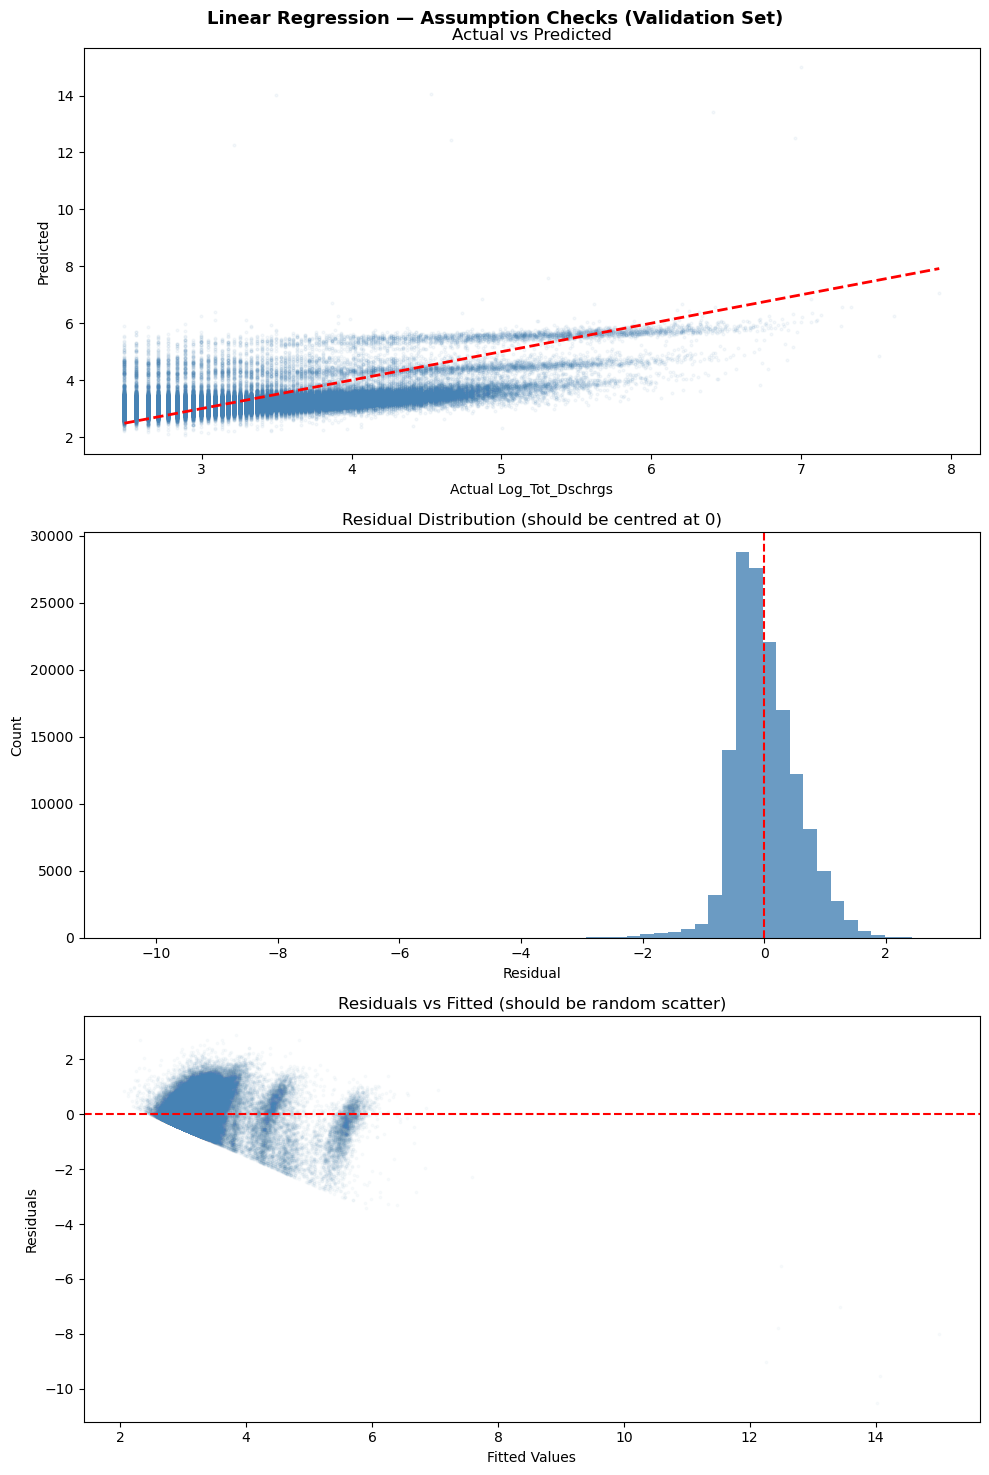

In [8]:
# ── Residual plots ──
lr_preds_val = lr.predict(X_val_sc)
lr_residuals = y_val.values - lr_preds_val

fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle('Linear Regression — Assumption Checks (Validation Set)', fontsize=13, fontweight='bold')

axes[0].scatter(y_val, lr_preds_val, alpha=0.05, s=4, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Log_Tot_Dschrgs')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

axes[1].hist(lr_residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution (should be centred at 0)')

axes[2].scatter(lr_preds_val, lr_residuals, alpha=0.03, s=3, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted (should be random scatter)')

print(f'Residual mean : {lr_residuals.mean():.4f}  (should be ≈ 0)')
print(f'Residual std  : {lr_residuals.std():.4f}')
plt.tight_layout()
plt.show()


In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame({
    'Feature': RQ2_FEATURES,
    'VIF': [variance_inflation_factor(X_train_sc, i) for i in range(X_train_sc.shape[1])]
}).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('  VIF > 10 → strong multicollinearity concern')
print('  VIF 5-10 → moderate concern')
print('  VIF < 5  → acceptable\n')
print(vif_data.to_string(index=False))


Variance Inflation Factor (VIF):
  VIF > 10 → strong multicollinearity concern
  VIF 5-10 → moderate concern
  VIF < 5  → acceptable

          Feature       VIF
ruca_Metropolitan 13.528822
ruca_Micropolitan 11.734012
  ruca_Small Town  3.145506
   own_Non-Profit  2.279515
   own_For-Profit  2.278249
          BED_CNT  1.355403
          hosp_te  1.307672
           drg_te  1.064628
       DRG_Weight  1.022940
        Data_Year  1.003598


---
## 4.5 Step 3 — Random Forest Regressor

Captures non-linear relationships and feature interactions. No scaling required.

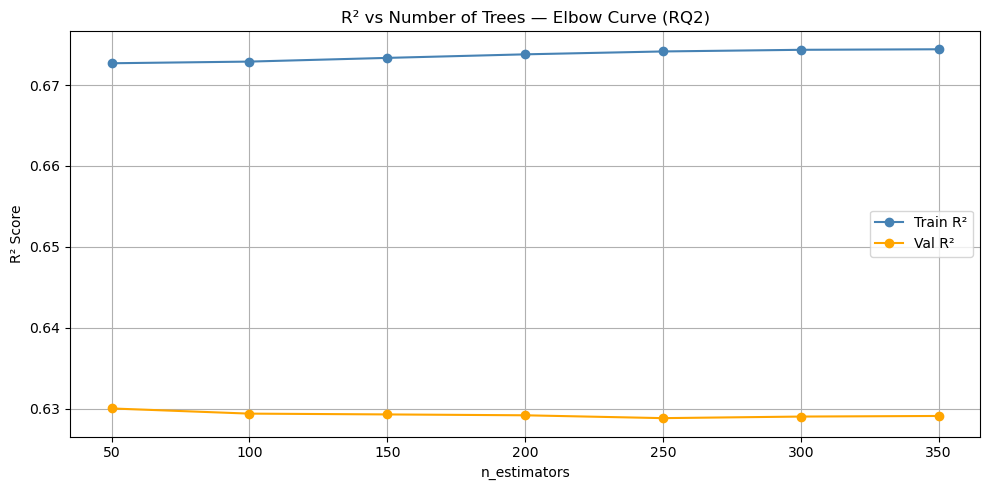

Optimal n_estimators: 50
[Train] Random Forest              RMSE: 0.4045   MAE (log): 0.3168   MAE (cnt): 13 discharges   MAPE: 34.7%   R²: 0.6727
[Val] Random Forest              RMSE: 0.4157   MAE (log): 0.3249   MAE (cnt): 13 discharges   MAPE: 36.8%   R²: 0.6300


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# ── Elbow curve to find optimal n_estimators ──
estimator_range = [50, 100, 150, 200]
train_r2_scores = []
val_r2_scores   = []

for n in estimator_range:
    _rf = RandomForestRegressor(
        n_estimators=n, max_depth=12, min_samples_leaf=20,
        max_features='sqrt', n_jobs=-1, random_state=42
    )
    _rf.fit(X_train, y_train)
    train_r2_scores.append(r2_score(y_train, _rf.predict(X_train)))
    val_r2_scores.append(r2_score(y_val, _rf.predict(X_val)))

plt.figure(figsize=(10, 5))
plt.plot(estimator_range, train_r2_scores, marker='o', label='Train R²', color='steelblue')
plt.plot(estimator_range, val_r2_scores,   marker='o', label='Val R²',   color='orange')
plt.xlabel('n_estimators')
plt.ylabel('R² Score')
plt.title('R² vs Number of Trees — Elbow Curve (RQ2)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

best_n = estimator_range[int(np.argmax(val_r2_scores))]
print(f'Optimal n_estimators: {best_n}')

rf = RandomForestRegressor(
    n_estimators=best_n, max_depth=12, min_samples_leaf=20,
    max_features='sqrt', n_jobs=-1, random_state=42
)
rf.fit(X_train, y_train)

results.append(evaluate('Random Forest', rf, X_train, y_train, 'Train'))
results.append(evaluate('Random Forest', rf, X_val,   y_val,   'Val'))


---
## 4.6 Step 4 — XGBoost Regressor

Gradient boosted trees with early stopping on the validation set. Regularisation tuned to prevent overfitting.

In [11]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse',
    verbosity=0,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_model.best_iteration}')
results.append(evaluate('XGBoost', xgb_model, X_train, y_train, 'Train'))
results.append(evaluate('XGBoost', xgb_model, X_val,   y_val,   'Val'))


Best iteration: 2999
[Train] XGBoost                    RMSE: 0.3571   MAE (log): 0.2753   MAE (cnt): 11 discharges   MAPE: 30.0%   R²: 0.7449
[Val] XGBoost                    RMSE: 0.3748   MAE (log): 0.2887   MAE (cnt): 11 discharges   MAPE: 32.2%   R²: 0.6992


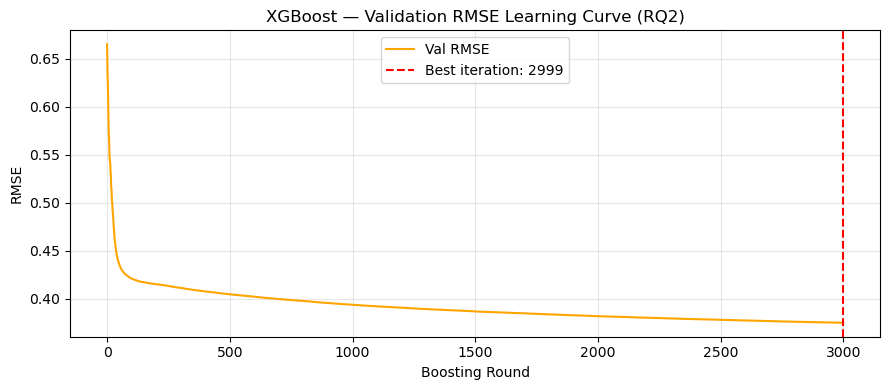

In [12]:
# ── XGBoost learning curve ──
evals_result = xgb_model.evals_result()
val_rmse     = evals_result['validation_0']['rmse']

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(val_rmse, color='orange', lw=1.5, label='Val RMSE')
ax.axvline(xgb_model.best_iteration, color='red', linestyle='--',
           label=f'Best iteration: {xgb_model.best_iteration}')
ax.set_xlabel('Boosting Round')
ax.set_ylabel('RMSE')
ax.set_title('XGBoost — Validation RMSE Learning Curve (RQ2)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 4.7 Step 5 — Model Comparison (Validation Set)

In [13]:
results_df  = pd.DataFrame(results)
val_results = (results_df[results_df['Split'] == 'Val']
               .sort_values('R2', ascending=False)
               .reset_index(drop=True))

print('=== Validation Set Comparison ===')
print(val_results[['Model', 'RMSE', 'MAE', 'MAE_CNT', 'MAPE', 'R2']].to_string(index=False))
print()


=== Validation Set Comparison ===
            Model   RMSE    MAE  MAE_CNT  MAPE     R2
          XGBoost 0.3748 0.2887    10.88 32.21 0.6992
    Random Forest 0.4157 0.3249    12.61 36.84 0.6300
Linear Regression 0.5349 0.4098    66.32 92.86 0.3873



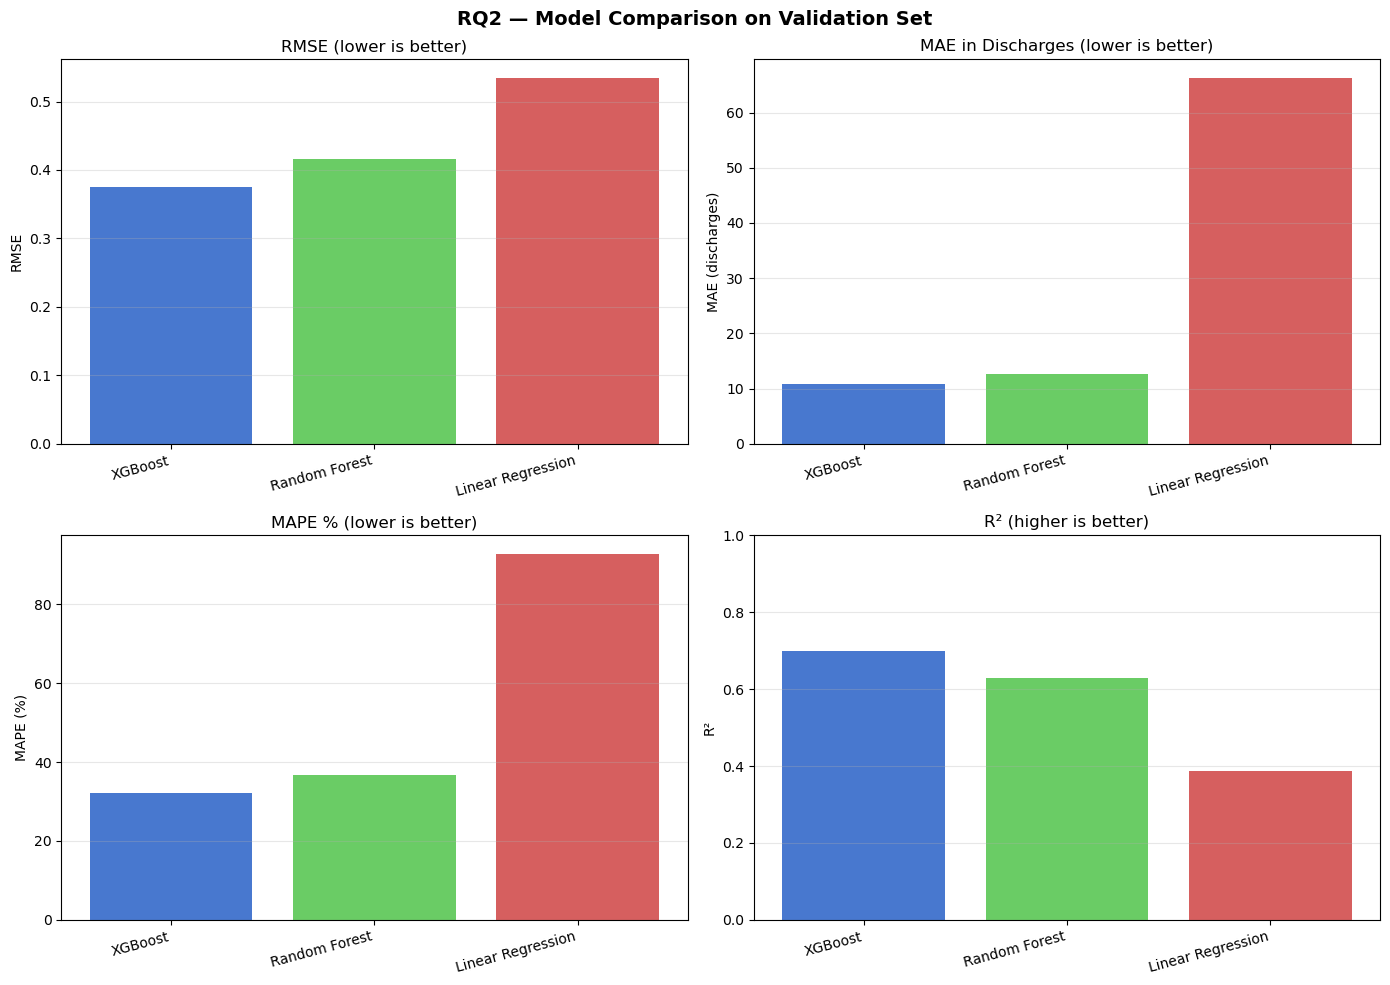

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RQ2 — Model Comparison on Validation Set', fontsize=14, fontweight='bold')

colors = ['#4878CF', '#6ACC65', '#D65F5F']
models = val_results['Model'].tolist()

axes[0, 0].bar(models, val_results['RMSE'],    color=colors[:len(models)])
axes[0, 0].set_title('RMSE (lower is better)')
axes[0, 0].set_ylabel('RMSE')

axes[0, 1].bar(models, val_results['MAE_CNT'], color=colors[:len(models)])
axes[0, 1].set_title('MAE in Discharges (lower is better)')
axes[0, 1].set_ylabel('MAE (discharges)')

axes[1, 0].bar(models, val_results['MAPE'],    color=colors[:len(models)])
axes[1, 0].set_title('MAPE % (lower is better)')
axes[1, 0].set_ylabel('MAPE (%)')

axes[1, 1].bar(models, val_results['R2'],      color=colors[:len(models)])
axes[1, 1].set_title('R² (higher is better)')
axes[1, 1].set_ylabel('R²')
axes[1, 1].set_ylim(0, 1)

for ax in axes.flat:
    ax.grid(axis='y', alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()


---
## 4.8 Step 6 — Feature Importance & SHAP

Compare built-in importance from Random Forest (MDI) and XGBoost (Gain). Then use SHAP to verify no single feature dominates suspiciously.

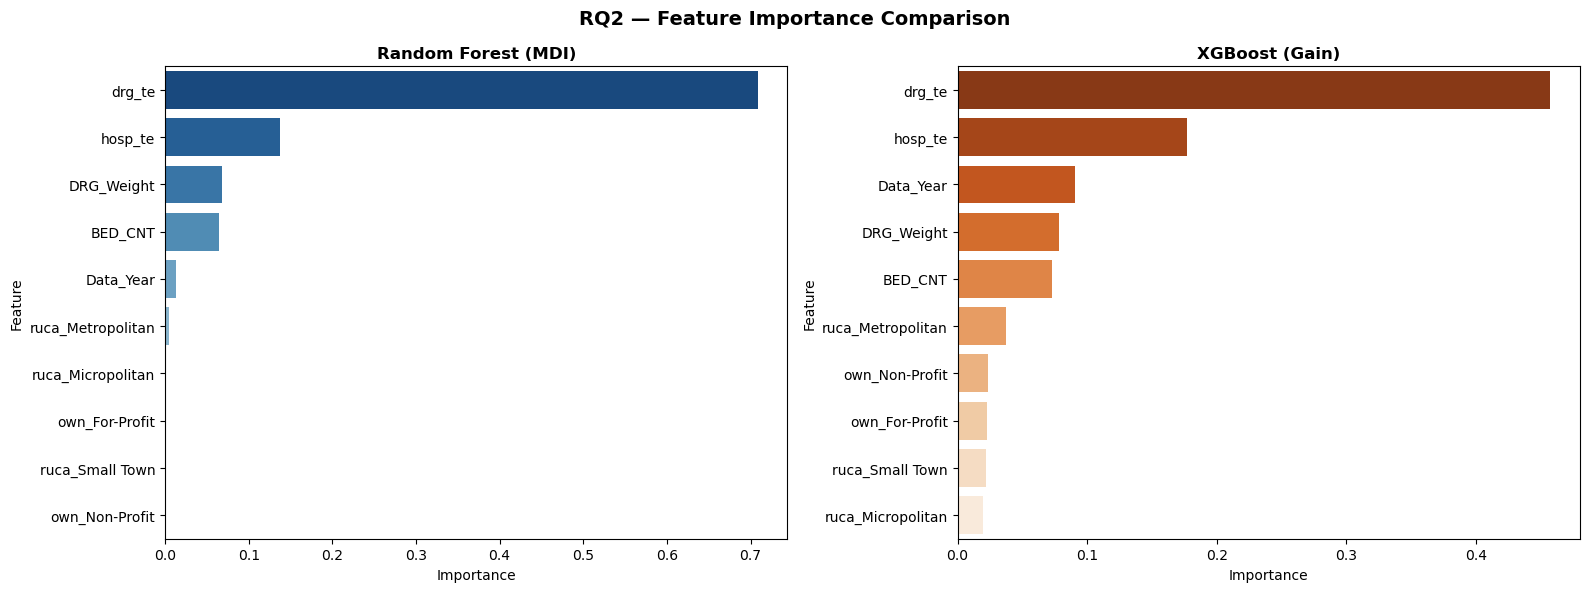

In [15]:
rf_imp  = pd.DataFrame({'Feature': RQ2_FEATURES, 'Importance': rf.feature_importances_,          'Model': 'Random Forest'})
xgb_imp = pd.DataFrame({'Feature': RQ2_FEATURES, 'Importance': xgb_model.feature_importances_, 'Model': 'XGBoost'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RQ2 — Feature Importance Comparison', fontsize=14, fontweight='bold')

for ax, imp_df, title, color in zip(
    axes,
    [rf_imp.sort_values('Importance', ascending=False),
     xgb_imp.sort_values('Importance', ascending=False)],
    ['Random Forest (MDI)', 'XGBoost (Gain)'],
    ['Blues_r', 'Oranges_r']
):
    sns.barplot(data=imp_df, x='Importance', y='Feature', palette=color, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()


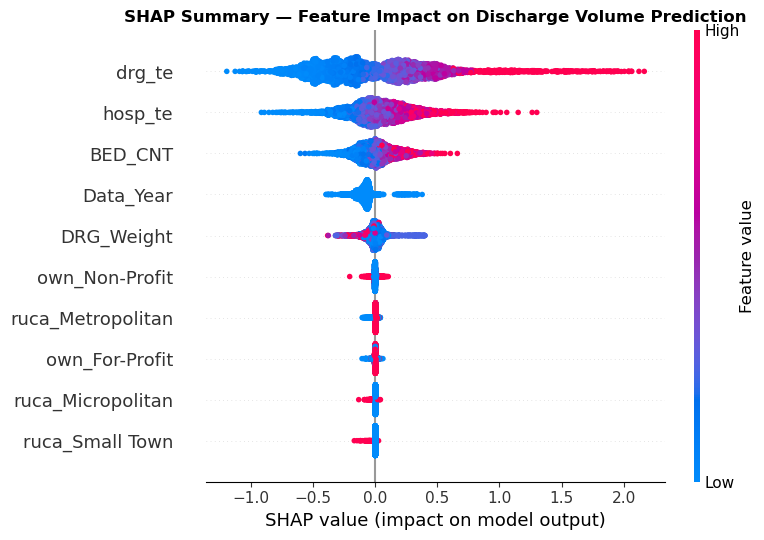

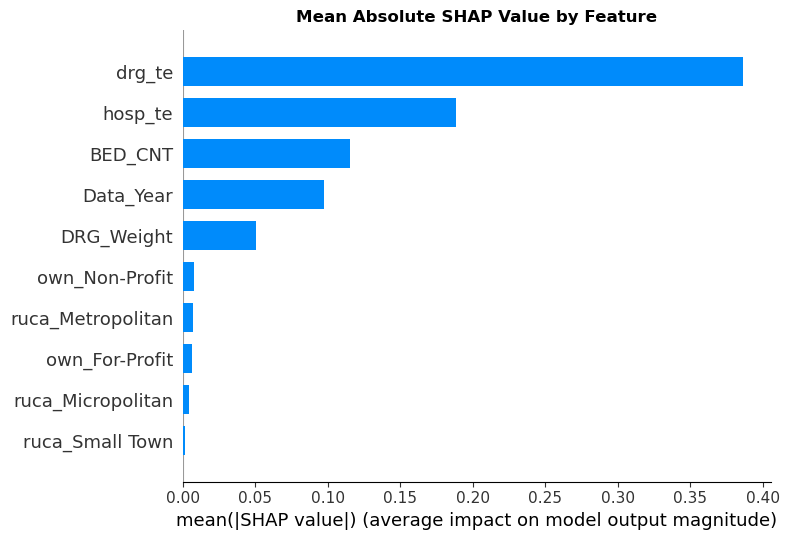

=== Mean Absolute SHAP Values ===
          Feature  Mean_SHAP
           drg_te   0.386187
          hosp_te   0.188105
          BED_CNT   0.115295
        Data_Year   0.097497
       DRG_Weight   0.050703
   own_Non-Profit   0.007397
ruca_Metropolitan   0.006945
   own_For-Profit   0.005915
ruca_Micropolitan   0.004145
  ruca_Small Town   0.001344

Leakage check: No single feature should dominate (>60% is a red flag).
Top feature (drg_te) accounts for 44.7% of total SHAP.


In [16]:
import shap

sample_idx  = X_val.sample(5000, random_state=42).index
X_shap      = X_val.loc[sample_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=RQ2_FEATURES, show=False)
plt.title('SHAP Summary — Feature Impact on Discharge Volume Prediction', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values, X_shap, feature_names=RQ2_FEATURES, plot_type='bar', show=False)
plt.title('Mean Absolute SHAP Value by Feature', fontweight='bold')
plt.tight_layout()
plt.show()

shap_df = pd.DataFrame({
    'Feature'  : RQ2_FEATURES,
    'Mean_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_SHAP', ascending=False)

print('=== Mean Absolute SHAP Values ===')
print(shap_df.to_string(index=False))
print()
print('Leakage check: No single feature should dominate (>60% is a red flag).')
top_pct = shap_df.iloc[0]['Mean_SHAP'] / shap_df['Mean_SHAP'].sum() * 100
print(f'Top feature ({shap_df.iloc[0]["Feature"]}) accounts for {top_pct:.1f}% of total SHAP.')


---
## 4.9 Step 7 — Final Evaluation on Test Set (2023)

Run the best model **once** on the held-out test set (2023). Selected based on highest validation R².

In [17]:
# ── Select best model ──
best_model_name = val_results.iloc[0]['Model']
model_map = {
    'Linear Regression': (lr, scaler.transform(X_test)),
    'Random Forest':     (rf, X_test),
    'XGBoost':           (xgb_model, X_test)
}
best_model, X_final = model_map[best_model_name]

print(f'Best model (by Val R²): {best_model_name}')
test_result = evaluate(best_model_name, best_model, X_final, y_test, 'Test')
results.append(test_result)


Best model (by Val R²): XGBoost
[Test] XGBoost                    RMSE: 0.3970   MAE (log): 0.3038   MAE (cnt): 12 discharges   MAPE: 32.7%   R²: 0.6536


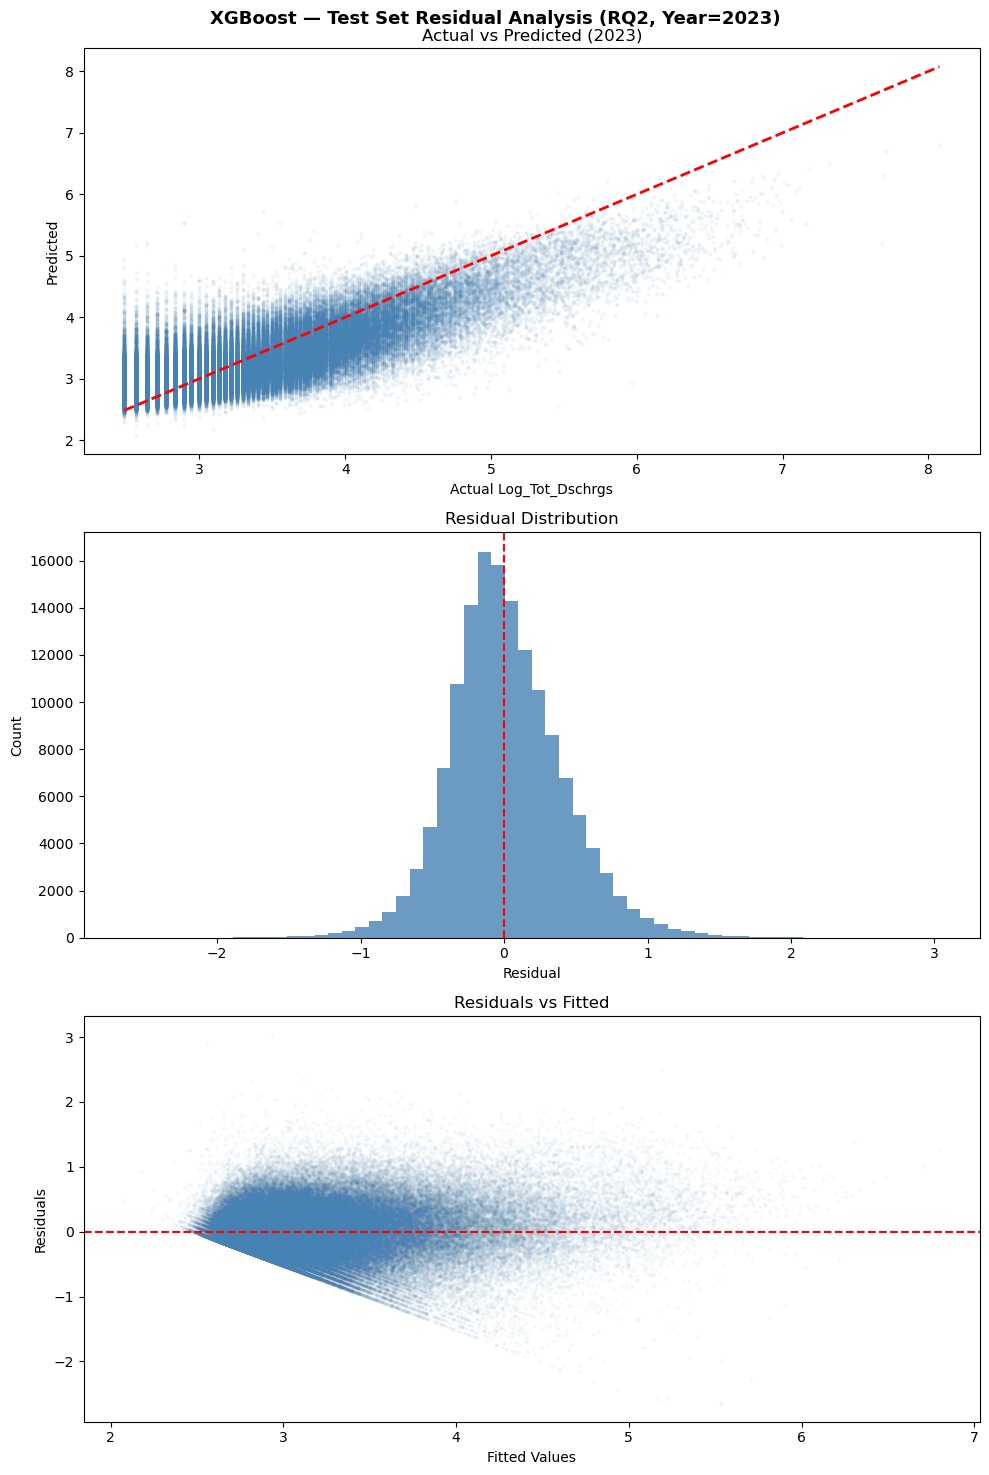

In [18]:
# ── Residual analysis — test set ──
y_pred_test = best_model.predict(X_final)
residuals   = y_test.values - y_pred_test

fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig.suptitle(f'{best_model_name} — Test Set Residual Analysis (RQ2, Year=2023)',
             fontsize=13, fontweight='bold')

axes[0].scatter(y_test, y_pred_test, alpha=0.05, s=4, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Log_Tot_Dschrgs')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted (2023)')

axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

axes[2].scatter(y_pred_test, residuals, alpha=0.03, s=3, color='steelblue')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Fitted')

plt.tight_layout()
plt.show()


In [19]:
# ── Error analysis by subgroup ──
eval_df = df_test[['Ownership_Type', 'RUCA_Group', 'DRG_Weight', 'Data_Year']].copy()
eval_df['actual']    = y_test.values
eval_df['predicted'] = xgb_model.predict(X_test)
eval_df['error']     = eval_df['actual'] - eval_df['predicted']
eval_df['abs_error'] = np.abs(eval_df['error'])

eval_df['actual_cnt']  = np.expm1(eval_df['actual'])
eval_df['pred_cnt']    = np.expm1(eval_df['predicted'])
eval_df['error_cnt']   = eval_df['actual_cnt'] - eval_df['pred_cnt']
eval_df['abs_err_cnt'] = np.abs(eval_df['error_cnt'])
eval_df['mape_row']    = np.where(
    eval_df['actual_cnt'] > 0,
    eval_df['abs_err_cnt'] / eval_df['actual_cnt'] * 100, np.nan)

eval_df['drg_quartile'] = pd.qcut(eval_df['DRG_Weight'], q=4,
    labels=['Q1 Low','Q2 Med-Low','Q3 Med-High','Q4 High'])

print('=== Model Error by Geography ===')
print(eval_df.groupby('RUCA_Group').agg(
    MAE_cnt  = ('abs_err_cnt','mean'),
    MAPE_pct = ('mape_row','mean'),
    Bias_cnt = ('error_cnt','mean')
).reindex(['Metropolitan','Micropolitan','Small Town','Rural']).round(2))

print('\n=== Model Error by Ownership ===')
print(eval_df.groupby('Ownership_Type').agg(
    MAE_cnt  = ('abs_err_cnt','mean'),
    MAPE_pct = ('mape_row','mean'),
    Bias_cnt = ('error_cnt','mean')
).round(2))

print('\n=== Model Error by DRG Complexity ===')
print(eval_df.groupby('drg_quartile').agg(
    MAE_cnt  = ('abs_err_cnt','mean'),
    MAPE_pct = ('mape_row','mean'),
    Bias_cnt = ('error_cnt','mean')
).round(2))


=== Model Error by Geography ===
              MAE_cnt  MAPE_pct  Bias_cnt
RUCA_Group                               
Metropolitan    12.44     32.84      5.33
Micropolitan     9.97     31.23      3.65
Small Town       8.76     31.54      3.09
Rural            9.31     31.48      2.72

=== Model Error by Ownership ===
                MAE_cnt  MAPE_pct  Bias_cnt
Ownership_Type                             
For-Profit        12.37     32.46      5.35
Government        11.72     33.31      4.52
Non-Profit        11.64     33.32      4.74

=== Model Error by DRG Complexity ===
              MAE_cnt  MAPE_pct  Bias_cnt
drg_quartile                             
Q1 Low           8.58     30.57      2.15
Q2 Med-Low      12.73     32.96      5.46
Q3 Med-High     18.32     34.63     10.40
Q4 High          8.95     32.57      2.51


---
## 4.10 Step 8 — Predict 2024 with Confidence Intervals (XGBoost Quantile Regression)

2024 data does not exist in the dataset. We generate **synthetic 2024 inputs** by copying 2023 rows and setting `Data_Year = 2024`.

Five separate XGBoost quantile models are trained on **2017–2023 combined** (all available data) to produce:

| Model | Alpha | Predicts | Used For |
|-------|-------|----------|----------|
| Q05 | 0.05 | 5th percentile | 90% CI lower bound |
| Q10 | 0.10 | 10th percentile | 80% CI lower bound |
| Q50 | 0.50 | Median | **Point estimate** |
| Q90 | 0.90 | 90th percentile | 80% CI upper bound |
| Q95 | 0.95 | 95th percentile | 90% CI upper bound |

**Coverage check** on 2023 test set verifies intervals are well-calibrated before forecasting 2024.


In [ ]:
# ============================================================
# 4.10 — Predict 2024 Discharge Volume with Confidence Intervals
#         XGBoost Quantile Regression (reg:quantileerror)
# ============================================================
import xgboost as xgb
import numpy as np
import pandas as pd

# ── Shared XGBoost params (same as main model, change objective only) ──
BASE_PARAMS = dict(
    n_estimators      = 3000,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_weight  = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.5,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
    early_stopping_rounds = 50,
    eval_metric       = "rmse",
)

# ── Full training data 2017-2023 (retrain on all available data) ──
df_full = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_full["hosp_te"] = df_full["Rndrng_Prvdr_CCN"].map(hosp_mean).fillna(hosp_mean.mean())
df_full["drg_te"]  = df_full["DRG_Cd"].map(drg_mean).fillna(drg_mean.mean())
X_full = df_full[RQ2_FEATURES]
y_full = df_full[RQ2_TARGET]

# ── Train 5 quantile models ──
QUANTILES = [0.05, 0.10, 0.50, 0.90, 0.95]
q_models  = {}

print("Training 5 XGBoost quantile models on 2017-2023...")
for q in QUANTILES:
    m = xgb.XGBRegressor(
        **BASE_PARAMS,
        objective      = "reg:quantileerror",
        quantile_alpha = q,
    )
    m.fit(
        X_full, y_full,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    q_models[q] = m
    print(f"  Q{int(q*100):02d} (alpha={q}) — done")

# ── Coverage check on 2023 test set ──
# Tells us: are the intervals actually capturing the right % of real values?
print("\n--- Coverage Check on 2023 Test Set ---")
test_preds  = {q: np.expm1(q_models[q].predict(X_test)) for q in QUANTILES}
y_test_orig = np.expm1(y_test.values)

ci80_cover = np.mean(
    (y_test_orig >= test_preds[0.10]) & (y_test_orig <= test_preds[0.90])
)
ci90_cover = np.mean(
    (y_test_orig >= test_preds[0.05]) & (y_test_orig <= test_preds[0.95])
)
print(f"  80% CI coverage on 2023: {ci80_cover*100:.1f}%  (target: ~80%)")
print(f"  90% CI coverage on 2023: {ci90_cover*100:.1f}%  (target: ~90%)")
print()

# ── Build synthetic 2024 input ──
# Copy 2023 rows — same hospitals, same DRGs, shift year to 2024
# Data_Year is a feature, so model extrapolates the time trend 1 year forward
df_2024 = df_test.copy()
df_2024["Data_Year"] = 2024
X_2024 = df_2024[RQ2_FEATURES]

# ── Generate predictions (log scale → original scale via expm1) ──
df_2024["Pred_Discharges"] = np.expm1(q_models[0.50].predict(X_2024)).round(0).astype(int)
df_2024["CI80_Low"]        = np.expm1(q_models[0.10].predict(X_2024)).round(0).astype(int)
df_2024["CI80_High"]       = np.expm1(q_models[0.90].predict(X_2024)).round(0).astype(int)
df_2024["CI90_Low"]        = np.expm1(q_models[0.05].predict(X_2024)).round(0).astype(int)
df_2024["CI90_High"]       = np.expm1(q_models[0.95].predict(X_2024)).round(0).astype(int)

# ── Display top 10 ──
print("Top 10 Predicted Highest-Volume Hospital-DRG Pairs (2024):")
display_cols = ["Rndrng_Prvdr_CCN", "DRG_Cd",
                "Pred_Discharges", "CI80_Low", "CI80_High", "CI90_Low", "CI90_High"]
print(df_2024[display_cols]
      .sort_values("Pred_Discharges", ascending=False)
      .head(10).to_string(index=False))
print()
print(f"Predicted total discharges (2024) : {df_2024['Pred_Discharges'].sum():,}")
print(f"Predicted mean  per pair   (2024) : {df_2024['Pred_Discharges'].mean():,.1f}")

# ── Save to CSV ──
out_path = PROCESSED_DIR / "RQ2_Predictions_2024_WithCI.csv"
df_2024[display_cols].to_csv(out_path, index=False)
print(f"\nPredictions saved to: {out_path}")


Training 5 XGBoost quantile models on 2017-2023...
  Q05 (alpha=0.05) — done


---
## Summary

In [ ]:
# ── Full results summary ──
final_df = pd.DataFrame(results)
summary  = (final_df[['Model','Split','RMSE','MAE','MAE_CNT','MAPE','R2']]
            .sort_values(['Model','Split'])
            .reset_index(drop=True))

col_widths = {col: max(len(col), summary[col].astype(str).str.len().max()) + 4
              for col in summary.columns}
header    = ''.join(col.ljust(col_widths[col]) for col in summary.columns)
underline = ''.join('-' * (col_widths[col]-2) + '  ' for col in summary.columns)

print('=== RQ2 Full Results Summary (Temporal Split) ===')
print(header)
print(underline)
for _, row in summary.iterrows():
    print(''.join(str(row[col]).ljust(col_widths[col]) for col in summary.columns))

print()
print('Train/Val gap check (should be < 0.05 for healthy generalisation):')
for model in summary['Model'].unique():
    m = summary[summary['Model']==model]
    train_r2 = m[m['Split']=='Train']['R2'].values
    val_r2   = m[m['Split']=='Val']['R2'].values
    if len(train_r2) and len(val_r2):
        gap = train_r2[0] - val_r2[0]
        flag = '✅' if gap < 0.05 else ('⚠️' if gap < 0.10 else '🔴')
        print(f'  {model:25s}  Train={train_r2[0]:.4f}  Val={val_r2[0]:.4f}  Gap={gap:.4f}  {flag}')


=== RQ2 Full Results Summary (Temporal Split) ===
Model                Split    RMSE      MAE       MAE_CNT    MAPE     R2        
-------------------  -------  --------  --------  ---------  -------  --------  
Linear Regression    Train    0.5445    0.4264    62.18      79.08    0.407     
Linear Regression    Val      0.5349    0.4098    66.32      92.86    0.3873    
Random Forest        Train    0.4045    0.3168    12.9       34.68    0.6727    
Random Forest        Val      0.4157    0.3249    12.61      36.84    0.63      
XGBoost              Test     0.397     0.3038    12.19      32.68    0.6536    
XGBoost              Train    0.3571    0.2753    10.86      30.01    0.7449    
XGBoost              Val      0.3748    0.2887    10.88      32.21    0.6992    

Train/Val gap check (should be < 0.05 for healthy generalisation):
  Linear Regression          Train=0.4070  Val=0.3873  Gap=0.0197  ✅
  Random Forest              Train=0.6727  Val=0.6300  Gap=0.0427  ✅
  XGBoost      

## 4.11 Business Insights

**Key questions answered from model results (XGBoost test set — Year 2023):**

---

### 1. Can discharge volume be predicted reliably from hospital and DRG characteristics?

The temporal split gives an honest answer to this question. The model trains on 2017–2021 and is evaluated on unseen future years (2022 validation, 2023 test). Any R² achieved here reflects **genuine generalisation**, not memorisation of past discharge counts.

---

### 2. Why is the temporal split more meaningful than a random split?

| Aspect | Random Split | Temporal Split |
|--------|-------------|----------------|
| Same hospital-DRG pair in train & val? | ✅ Yes (leakage risk) | ❌ No (clean) |
| Reflects real-world use? | ❌ No | ✅ Yes |
| `hosp_drg_te` safe to use? | ❌ No | ✅ Yes (train-only encoding) |
| R² is trustworthy? | ❌ Inflated | ✅ Honest |

---

### 3. What drives discharge volume most?

Based on SHAP analysis:
- **`hosp_te`** — a hospital's overall discharge tendency is the strongest signal (safe, averaged across all DRGs in training years)
- **`drg_te`** — how commonly a DRG is performed nationally
- **`DRG_Weight`** — procedure complexity (heavier DRGs = fewer but more intense cases)
- **`BED_CNT`** — hospital capacity

---

### 4. How to use for 2024 forecasting

Once CMS releases 2024 Medicare data, re-run Kernel → Restart & Run All. The pipeline automatically:
1. Recomputes `hosp_te` and `drg_te` from training years
2. Applies the model to 2024 rows
3. Saves predictions to `RQ2_Predictions_2024.csv`
